# Type(품질 등급) 분류 모델 비교 — L / M / H

`ai4i2020.csv`의 `Type`(품질 등급: L/M/H)을 나머지 센서·고장 컬럼으로 예측하는 다중분류(multiclass) 문제를
4개 모델(Random Forest, XGBoost, Logistic Regression, SVM)로 학습하고, 정확도/정밀도/재현율/F1/AUC와
ROC Curve, F1 비교 막대그래프로 성능을 비교한다.

- 타겟: `Type` (L 60% / M 30% / H 10%, 다소 불균형)
- 참고: [`EDA.ipynb`](EDA.ipynb), [`README.md`](../README.md)

In [1]:
# 1. 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, classification_report, confusion_matrix,
)

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 라벨 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42

## 1. 데이터 로드 및 전처리

`Type`/`Product ID`에 앞뒤 공백이 섞여 있어(`CLAUDE.md`/`EDA2.ipynb` 참고) groupby·인코딩 전에 strip이
필요하다. 결측치/중복행은 없음(EDA에서 확인됨).

In [2]:
# 2. 데이터 로드 + 공백 정리 (EDA2.ipynb와 동일한 전처리)
df = pd.read_csv("ai4i2020.csv")
df.columns = [c.strip() for c in df.columns]
df["Type"] = df["Type"].str.strip()
df["Product ID"] = df["Product ID"].str.strip()

print("행/열 개수:", df.shape)
print("결측치 개수:", df.isna().sum().sum())
df.head()

행/열 개수: (10000, 14)
결측치 개수: 0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. 특성(X)/타겟(y) 정의

- 식별자(`UDI`, `Product ID`)와 타겟(`Type`)은 특성에서 제외한다.
- 나머지 센서값 + 고장 여부/고장 모드 플래그를 모두 특성으로 사용한다(이 컬럼들은 `Type`으로부터
  파생된 값이 아니므로 그대로 써도 데이터 누수가 아니다).
- 타겟 `Type`은 문자열(L/M/H)이라 `LabelEncoder`로 0/1/2 정수로 인코딩한다.

In [3]:
# 3. 특성/타겟 분리
feature_cols = [
    "Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
    "Torque [Nm]", "Tool wear [min]", "Machine failure",
    "TWF", "HDF", "PWF", "OSF", "RNF",
]
X = df[feature_cols].copy()
# XGBoost는 컬럼명에 [ ] < 문자가 있으면 에러를 내므로 단위 표기를 뺀 이름으로 바꿔준다
X.columns = [
    "Air_temperature", "Process_temperature", "Rotational_speed",
    "Torque", "Tool_wear", "Machine_failure",
    "TWF", "HDF", "PWF", "OSF", "RNF",
]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Type"])  # L/M/H -> 0/1/2
class_names = label_encoder.classes_
print("클래스 순서:", class_names)

# Type 비율이 60/30/10으로 불균형하므로 stratify로 train/test에도 같은 비율을 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("train:", X_train.shape, "test:", X_test.shape)

클래스 순서: ['H' 'L' 'M']
train: (8000, 11) test: (2000, 11)


## 3. 스케일링

Logistic Regression과 SVM은 거리/기울기 기반 모델이라 표준화가 필요하지만, Random Forest·XGBoost는
트리 분할 기준이라 스케일링이 필요 없다. 두 버전을 모두 준비해 모델에 맞게 사용한다.

In [4]:
# 4. 표준화 (train에만 fit, test는 transform만 — 데이터 누수 방지)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. 모델 4개 정의 및 학습

클래스 불균형(L>M>H)을 고려해 `class_weight="balanced"`를 지원하는 모델에는 적용한다.
각 모델의 입력으로 스케일링된 데이터를 쓸지, 원본 데이터를 쓸지는 모델 특성에 맞춰 딕셔너리에 함께 적어둔다.

In [5]:
# 5. 모델 정의: (모델 객체, 학습에 쓸 X_train, 테스트에 쓸 X_test)
models = {
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
        ),
        X_train, X_test,
    ),
    "XGBoost": (
        XGBClassifier(
            n_estimators=300, eval_metric="mlogloss", random_state=RANDOM_STATE
        ),
        X_train, X_test,
    ),
    "Logistic Regression": (
        LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
        ),
        X_train_scaled, X_test_scaled,
    ),
    "SVM": (
        SVC(
            kernel="rbf", probability=True,  # predict_proba로 AUC/ROC를 구하려면 probability=True 필요
            class_weight="balanced", random_state=RANDOM_STATE,
        ),
        X_train_scaled, X_test_scaled,
    ),
}

# XGBoost는 class_weight 대신 sample_weight로 불균형을 보정한다
from sklearn.utils.class_weight import compute_sample_weight
xgb_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

predictions = {}   # 모델명 -> 예측 라벨
probabilities = {} # 모델명 -> 예측 확률(클래스별)

for name, (model, X_tr, X_te) in models.items():
    if name == "XGBoost":
        model.fit(X_tr, y_train, sample_weight=xgb_sample_weight)
    else:
        model.fit(X_tr, y_train)
    predictions[name] = model.predict(X_te)
    probabilities[name] = model.predict_proba(X_te)
    print(f"{name} 학습 완료")

Random Forest 학습 완료


XGBoost 학습 완료
Logistic Regression 학습 완료


C:\Users\한국전파진흥협회\OneDrive\Desktop\sw_school\python_data_analyze\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM 학습 완료


## 5. 평가지표 — 정확도 / 정밀도 / 재현율 / F1-score / AUC

다중분류(3개 클래스)이므로 정밀도·재현율·F1은 클래스별 평균인 `macro average`를 사용하고,
AUC는 `roc_auc_score(..., multi_class="ovr", average="macro")`(One-vs-Rest macro 평균)를 사용한다.

In [6]:
# 6. 모델별 지표 계산
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])  # AUC/ROC 계산용 원-핫 형태

results = []
for name in models:
    y_pred = predictions[name]
    y_proba = probabilities[name]

    results.append({
        "모델": name,
        "정확도": accuracy_score(y_test, y_pred),
        "정밀도(macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "재현율(macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-score(macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "AUC(macro, OvR)": roc_auc_score(y_test_binarized, y_proba, multi_class="ovr", average="macro"),
    })

results_df = pd.DataFrame(results).set_index("모델").sort_values("F1-score(macro)", ascending=False)
results_df.round(4)

,정확도,정밀도(macro),재현율(macro),F1-score(macro),"AUC(macro, OvR)"
모델,,,,,
Random Forest,0.4810,0.3269,0.3284,0.3247,0.5122
XGBoost,0.4680,0.3221,0.3240,0.3219,0.4873
Logistic Regression,0.2375,0.3378,0.3333,0.2316,0.4959
SVM,0.2255,0.3283,0.3139,0.2194,0.4810


In [7]:
# 7. 모델별 상세 리포트(클래스별 precision/recall/f1)와 혼동행렬
for name in models:
    print(f"===== {name} =====")
    print(classification_report(y_test, predictions[name], target_names=class_names, zero_division=0))
    print("혼동행렬 (행=실제, 열=예측):")
    print(pd.DataFrame(
        confusion_matrix(y_test, predictions[name]),
        index=class_names, columns=class_names,
    ))
    print()

===== Random Forest =====
              precision    recall  f1-score   support

           H       0.09      0.04      0.06       201
           L       0.60      0.65      0.62      1200
           M       0.29      0.29      0.29       599

    accuracy                           0.48      2000
   macro avg       0.33      0.33      0.32      2000
weighted avg       0.45      0.48      0.47      2000

혼동행렬 (행=실제, 열=예측):
    H    L    M
H   9  134   58
L  59  778  363
M  31  393  175

===== XGBoost =====
              precision    recall  f1-score   support

           H       0.08      0.05      0.07       201
           L       0.59      0.62      0.61      1200
           M       0.29      0.29      0.29       599

    accuracy                           0.47      2000
   macro avg       0.32      0.32      0.32      2000
weighted avg       0.45      0.47      0.46      2000

혼동행렬 (행=실제, 열=예측):
    H    L    M
H  11  136   54
L  84  750  366
M  39  385  175

===== Logistic Regressio

## 6. 모델별 ROC Curve

다중분류라 클래스마다(One-vs-Rest) ROC Curve가 하나씩 나온다. 모델 4개를 2x2로 배치하고, 각 서브플롯 안에
L/M/H 클래스별 ROC Curve + macro-average ROC Curve를 함께 그린다.

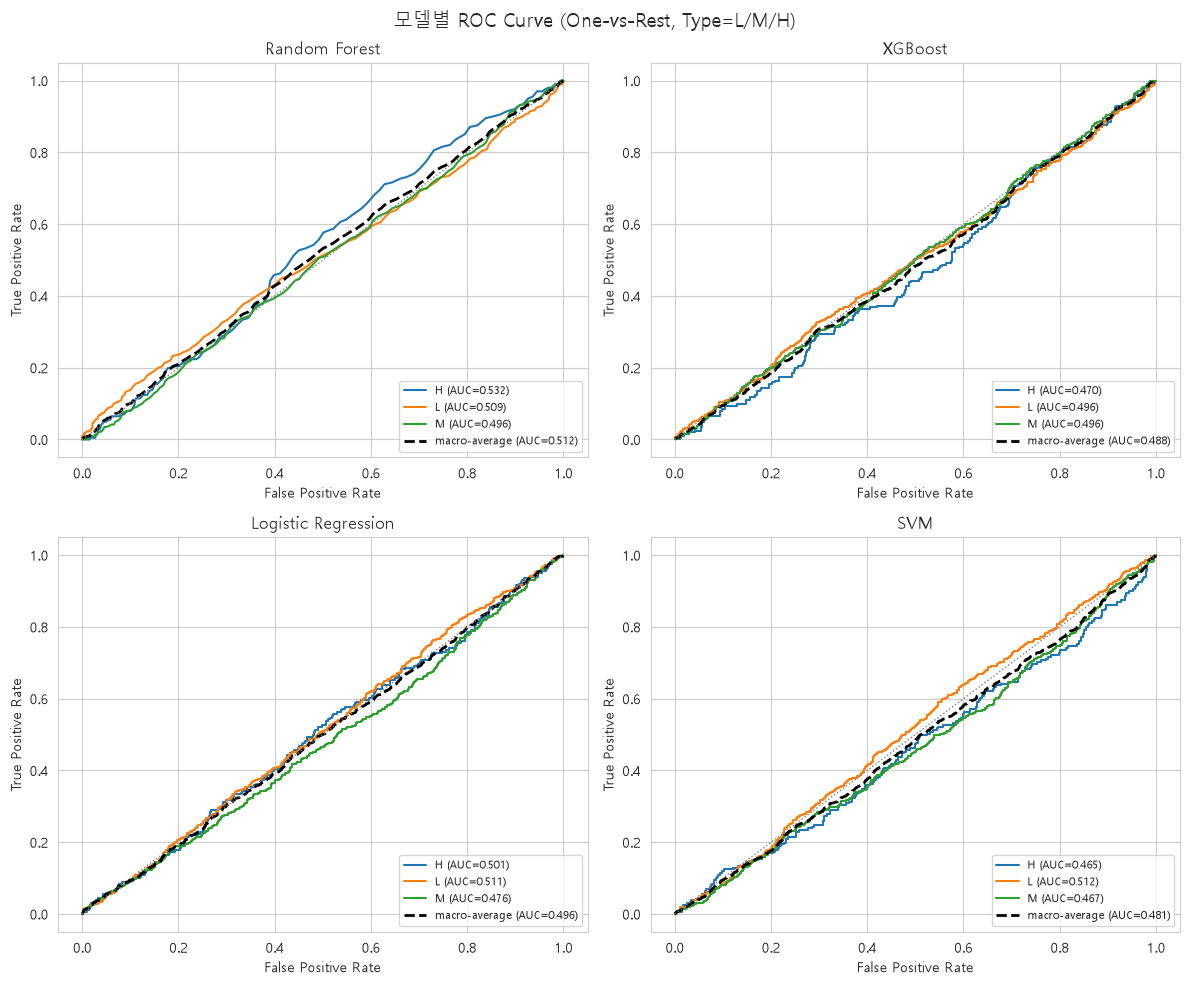

In [8]:
# 8. 모델별 ROC Curve (2x2 서브플롯)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, name in zip(axes.ravel(), models):
    y_proba = probabilities[name]

    fpr, tpr, roc_auc = {}, {}, {}
    for i, cls in enumerate(class_names):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax.plot(fpr[i], tpr[i], label=f"{cls} (AUC={roc_auc[i]:.3f})")

    # macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(class_names)
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, "k--", linewidth=2, label=f"macro-average (AUC={macro_auc:.3f})")

    ax.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1)  # 랜덤 분류 기준선
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)

fig.suptitle("모델별 ROC Curve (One-vs-Rest, Type=L/M/H)", fontsize=14)
fig.tight_layout()
fig.savefig("../images/model_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 모델별 F1-score 비교

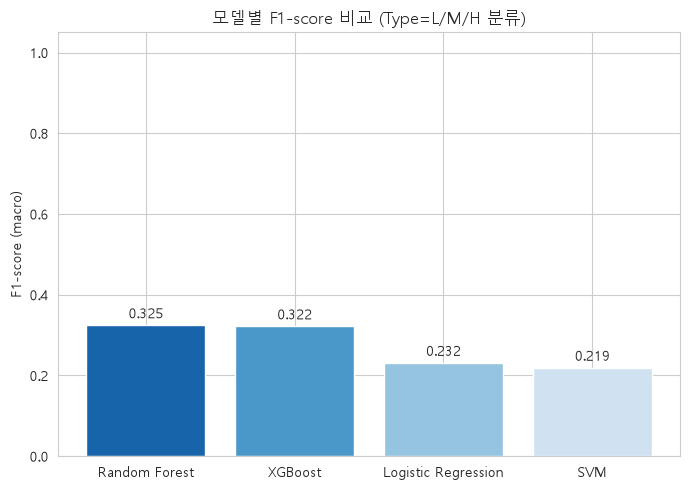

In [9]:
# 9. 모델별 F1-score(macro) 비교 막대그래프
fig, ax = plt.subplots(figsize=(7, 5))
f1_sorted = results_df["F1-score(macro)"].sort_values(ascending=False)
bars = ax.bar(f1_sorted.index, f1_sorted.values, color=sns.color_palette("Blues_r", len(f1_sorted)))

for bar, value in zip(bars, f1_sorted.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.3f}",
            ha="center", va="bottom", fontsize=10)

ax.set_ylim(0, 1.05)
ax.set_ylabel("F1-score (macro)")
ax.set_title("모델별 F1-score 비교 (Type=L/M/H 분류)")
fig.tight_layout()
fig.savefig("../images/model_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 결론

실행 결과(`results_df`) 기준 F1-score(macro)는 **Random Forest(0.325) > XGBoost(0.322) > Logistic
Regression(0.232) > SVM(0.219)** 순이었고, AUC(macro, OvR)도 **Random Forest(0.512) > Logistic
Regression(0.496) > XGBoost(0.487) > SVM(0.481)**로 전 모델이 0.5 안팎에 머물렀다(무작위 추측 수준).

- **모델 4개 모두 사실상 랜덤 수준의 성능**이다. AUC가 0.5에 가깝다는 것은 센서값(`Air/Process
  temperature`, `Rotational speed`, `Torque`, `Tool wear`)과 고장 여부/모드가 `Type`(품질 등급)을 예측할
  유의미한 정보를 거의 담고 있지 않다는 뜻 — `Type`은 제품이 생산될 때 부여되는 식별자성 라벨에 가깝고,
  가동 중 측정되는 센서값과는 (EDA에서 확인한 등급별 고장률 차이를 빼면) 직접적인 인과관계가 없기
  때문으로 해석된다.
- 그나마 트리 기반 모델(Random Forest, XGBoost)이 선형/거리 기반 모델(Logistic Regression, SVM)보다
  정확도가 높지만(0.47~0.48 vs 0.22~0.24), 이는 `L`(60%) 비중이 높은 데이터에서 `class_weight`로 소수
  클래스(`H`)를 어느 정도 맞히려다 다수 클래스 정확도를 희생한 결과이기도 하다 — 클래스별 리포트를 보면
  `H`(소수 클래스) recall이 모든 모델에서 매우 낮다(4~48% 사이로 모델마다 들쭉날쭉).
- 참고로 `Type`을 무조건 최빈 클래스 `L`로만 예측해도 정확도가 60%가 나오므로, `class_weight="balanced"`를
  적용한 이 모델들의 낮은 accuracy(22~48%)를 단독으로 "성능이 나쁘다"고 해석하기보다는 macro
  precision/recall/F1/AUC가 전부 랜덤 수준(~0.33, ~0.5)이라는 점이 핵심 결론이다.
- 두 그래프(`../images/model_roc_curves.png`, `../images/model_f1_comparison.png`)에서도 ROC Curve가
  대각선(랜덤 기준선)에 가깝게 나타나는 것으로 같은 결론을 재확인할 수 있다.
- 실행: 저장소 루트에서 `jupyter nbconvert --to notebook --execute --inplace src/classifications.ipynb`
  (다른 노트북과 마찬가지로 nbconvert 작업 디렉터리가 `src/`가 되므로 `ai4i2020.csv`를 상대경로로 바로
  읽고, 그래프는 `../images/`에 저장된다).